<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>08 → Multilayer Perceptron (MLP) Neural Network Classification</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">(Deep Feedforward Neural Networks, Activation Functions, Loss Landscapes, Non-Linear Decision Boundaries)</span>
</div>


---

# Table of Contents 

1. [Task 1: Foundations of Artificial Neural Networks & Multi-Layer Perceptrons](#1-neural-network-foundations)
2. [Task 2: Non-Linear Activation Functions & Gradients (Sigmoid, Tanh, ReLU, LeakyReLU)](#2-activation-functions)
3. [Task 3: Import Libraries & Generate Non-Linear Datasets (Moons & Circles)](#3-import-libraries-data)
4. [Task 4: Feature Preprocessing & Stratified Train-Test Splitting](#4-preprocessing-split)
5. [Task 5: Building & Training the Baseline MLP Classifier](#5-baseline-mlp)
6. [Task 6: Training Dynamics: Loss Convergence Trajectory (`loss_curve_`)](#6-loss-curve-convergence)
7. [Task 7: Visualizing Decision Boundary Evolution across Network Depth & Neurons](#7-depth-capacity-boundaries)
8. [Task 8: Activation Function Comparison on Decision Surfaces (Identity vs Logistic vs Tanh vs ReLU)](#8-activation-comparison)
9. [Task 9: Regularization & Overfitting Control (L2 Penalty alpha)](#9-regularization-alpha)
10. [Task 10: Optimizer Convergence Shootout (Adam vs SGD with Momentum vs L-BFGS)](#10-optimizer-shootout)
11. [Task 11: Generalization Benchmark on Concentric Circles Geometry](#11-circles-geometry)
12. [Task 12: Hyperparameter Tuning via GridSearchCV](#12-mlp-gridsearch)
13. [Task 13: Final Optimized MLP Model Evaluation (Contour Probability, Confusion Matrix, ROC-AUC)](#13-final-evaluation)
14. [Task 14: Deep Learning Engineering Takeaways & Scaling to Deep Architectures](#14-summary-takeaways)

---


<a id="1-neural-network-foundations"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Task 1: Foundations of Artificial Neural Networks & Multi-Layer Perceptrons</span>


A **Multi-Layer Perceptron (MLP)** is a deep feedforward artificial neural network architecture composed of sequentially connected layers of artificial neurons (perceptrons):

1. **Input Layer $\mathbf{x} \in \mathbb{R}^{d}$:** Receives raw feature dimensions.
2. **Hidden Layer(s) $\mathbf{h}^{(l)} \in \mathbb{R}^{m_l}$:** Compute non-linear intermediate representations:

$$
\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}, \quad \mathbf{h}^{(l)} = g\left( \mathbf{z}^{(l)} \right)
$$

where $\mathbf{W}^{(l)}$ is the weight matrix, $\mathbf{b}^{(l)}$ is the bias vector, and $g(\cdot)$ is an element-wise non-linear activation function.

3. **Output Layer $\hat{\mathbf{y}}$:** Produces probabilities (via Sigmoid for binary classification or Softmax for multiclass).

### The Universal Approximation Theorem (Cybenko, 1989; Hornik, 1991)
A standard feedforward neural network with a single hidden layer containing a finite number of neurons and continuous non-linear activation functions can approximate any continuous function on compact subsets of $\mathbb{R}^d$ to arbitrary precision.

### Backpropagation & Gradient Descent
Weights are optimized by propagating output errors backwards via the **chain rule of calculus**:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} = \frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}} \left(\mathbf{h}^{(l-1)}\right)^T, \quad \mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \left( \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}} + \alpha \mathbf{W}^{(l)} \right)
$$

where $\eta$ is the learning rate and $\alpha$ is the $L_2$ weight regularization penalty.


<a id="2-activation-functions"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 2: Non-Linear Activation Functions & Gradients (Sigmoid, Tanh, ReLU, LeakyReLU)</span>


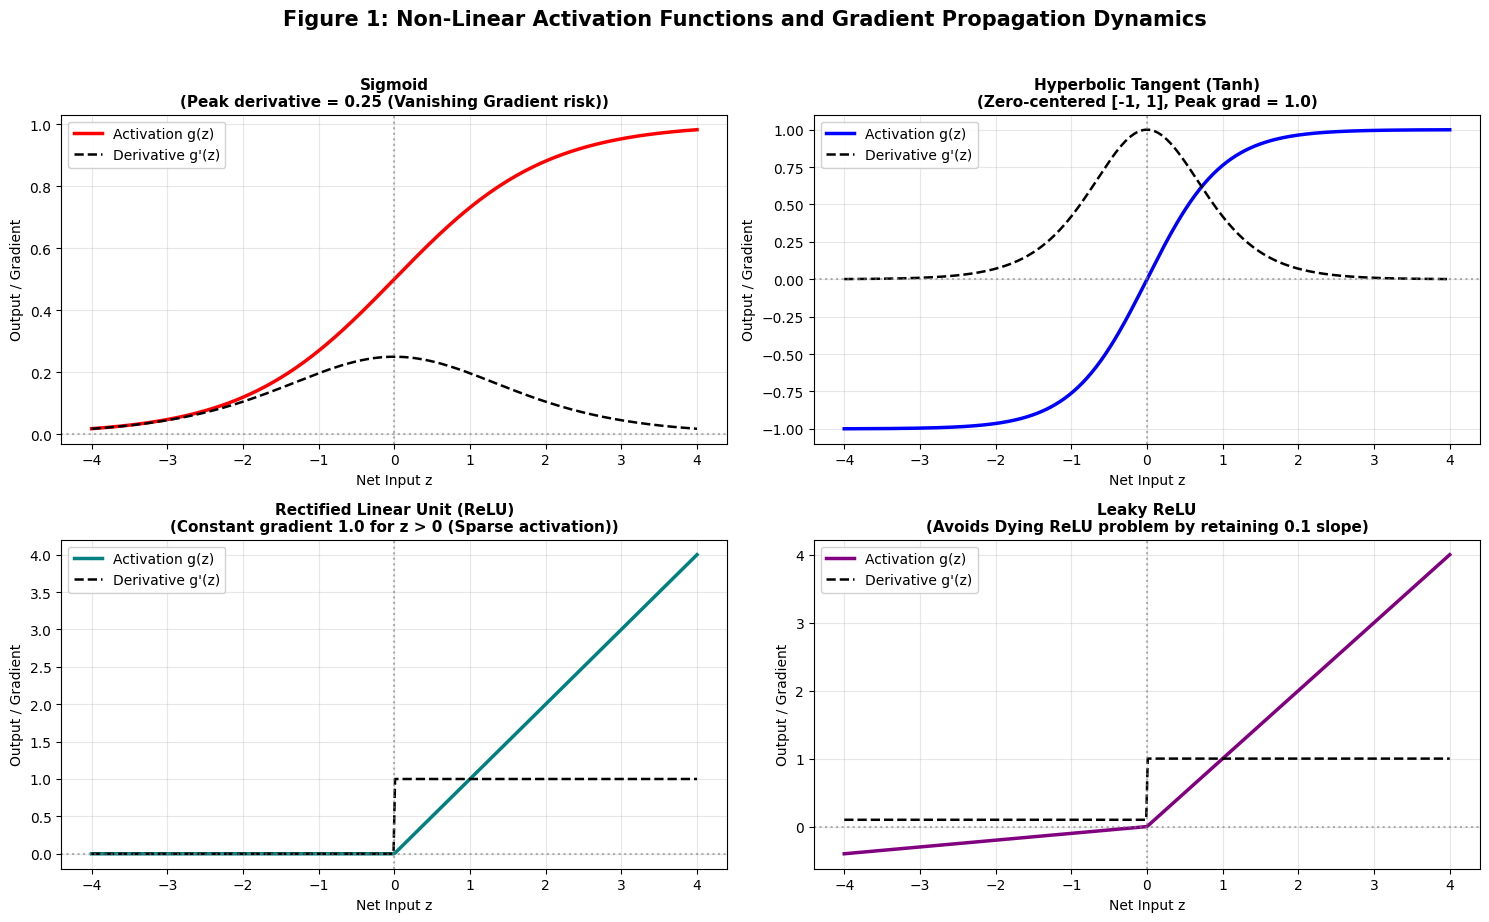

In [1]:
# PLOT 1: Activation Functions and Their Analytical Gradients
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-4, 4, 400)

# Definitions
sigmoid = 1 / (1 + np.exp(-z))
d_sigmoid = sigmoid * (1 - sigmoid)

tanh = np.tanh(z)
d_tanh = 1 - tanh**2

relu = np.maximum(0, z)
d_relu = np.where(z > 0, 1.0, 0.0)

leaky_relu = np.where(z > 0, z, 0.1 * z)
d_leaky_relu = np.where(z > 0, 1.0, 0.1)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

funcs = [
    ("Sigmoid", sigmoid, d_sigmoid, 'red', 'Peak derivative = 0.25 (Vanishing Gradient risk)'),
    ("Hyperbolic Tangent (Tanh)", tanh, d_tanh, 'blue', 'Zero-centered [-1, 1], Peak grad = 1.0'),
    ("Rectified Linear Unit (ReLU)", relu, d_relu, 'teal', 'Constant gradient 1.0 for z > 0 (Sparse activation)'),
    ("Leaky ReLU", leaky_relu, d_leaky_relu, 'purple', 'Avoids Dying ReLU problem by retaining 0.1 slope')
]

for idx, (name, val, grad, color, desc) in enumerate(funcs):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    ax.plot(z, val, color=color, linewidth=2.5, label='Activation g(z)')
    ax.plot(z, grad, color='black', linestyle='--', linewidth=1.8, label="Derivative g'(z)")
    ax.axhline(0, color='gray', linestyle=':', alpha=0.6)
    ax.axvline(0, color='gray', linestyle=':', alpha=0.6)
    ax.set_title(f"{name}\n({desc})", fontweight='bold', fontsize=11)
    ax.set_xlabel("Net Input z")
    ax.set_ylabel("Output / Gradient")
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Figure 1: Non-Linear Activation Functions and Gradient Propagation Dynamics", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="3-import-libraries-data"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 3: Import Libraries & Generate Non-Linear Datasets (Moons & Circles)</span>


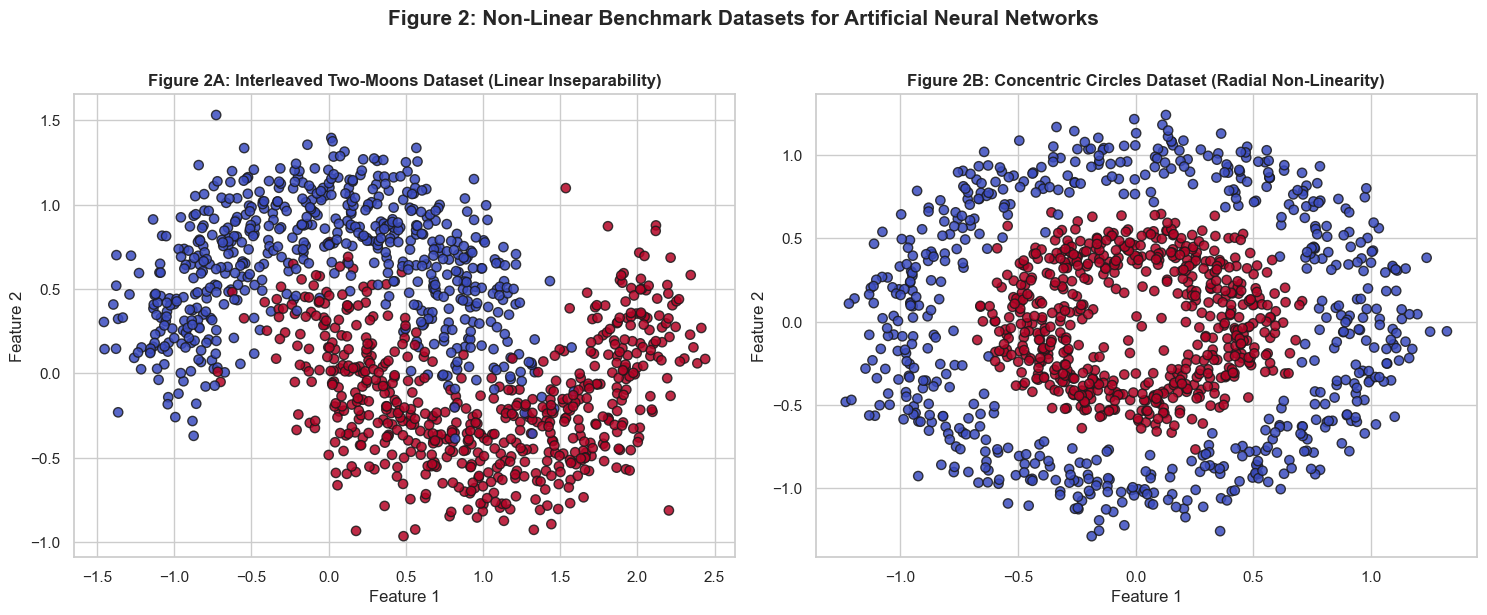

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

# Configure plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 11

# Generate synthetic non-linear benchmarks
X_moons, y_moons = make_moons(n_samples=1200, noise=0.22, random_state=42)
X_circles, y_circles = make_circles(n_samples=1200, noise=0.12, factor=0.45, random_state=42)

# PLOT 2: Side-by-Side Visualization of Non-Linear Benchmark Geometries
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm',
                       edgecolor='k', s=45, alpha=0.85)
ax1.set_title("Figure 2A: Interleaved Two-Moons Dataset (Linear Inseparability)", fontweight='bold')
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

scatter2 = ax2.scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='coolwarm',
                       edgecolor='k', s=45, alpha=0.85)
ax2.set_title("Figure 2B: Concentric Circles Dataset (Radial Non-Linearity)", fontweight='bold')
ax2.set_xlabel("Feature 1")
ax2.set_ylabel("Feature 2")

plt.suptitle("Figure 2: Non-Linear Benchmark Datasets for Artificial Neural Networks", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="4-preprocessing-split"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 4: Feature Preprocessing & Stratified Train-Test Splitting</span>


In [3]:
# Train-test split (75% train, 25% test) with stratification
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42, stratify=y_moons
)

# Feature standardization is vital for neural network gradient backpropagation!
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training partition: {X_train.shape[0]} samples (Class 0: {np.sum(y_train==0)}, Class 1: {np.sum(y_train==1)})")
print(f"Testing partition:  {X_test.shape[0]} samples (Class 0: {np.sum(y_test==0)}, Class 1: {np.sum(y_test==1)})")

Training partition: 900 samples (Class 0: 450, Class 1: 450)
Testing partition:  300 samples (Class 0: 150, Class 1: 150)


<a id="5-baseline-mlp"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 5: Building & Training the Baseline MLP Classifier</span>


In [4]:
# Initialize and train baseline MLP: 2 hidden layers (16, 16 neurons), ReLU, Adam optimizer
mlp_base = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.01,
    max_iter=500,
    random_state=42
)
mlp_base.fit(X_train, y_train)

y_pred_base = mlp_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"Baseline MLP Training Converged in {mlp_base.n_iter_} iterations.")
print(f"Test Accuracy: {acc_base * 100:.2f}%\n")
print("Baseline Classification Report:")
print(classification_report(y_test, y_pred_base))

Baseline MLP Training Converged in 68 iterations.
Test Accuracy: 96.67%

Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       150
           1       0.99      0.95      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



<a id="6-loss-curve-convergence"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 6: Training Dynamics: Loss Convergence Trajectory (`loss_curve_`)</span>


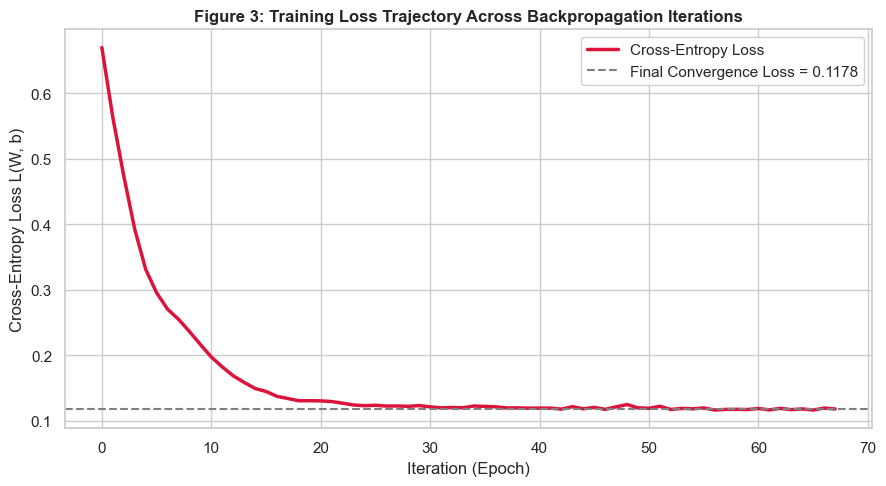

In [5]:
# PLOT 3: Training Loss Convergence Curve Across Epochs
plt.figure(figsize=(9, 5))
plt.plot(mlp_base.loss_curve_, color='crimson', linewidth=2.5, label='Cross-Entropy Loss')
plt.axhline(mlp_base.loss_curve_[-1], color='gray', linestyle='--',
            label=f'Final Convergence Loss = {mlp_base.loss_curve_[-1]:.4f}')
plt.title("Figure 3: Training Loss Trajectory Across Backpropagation Iterations", fontweight='bold')
plt.xlabel("Iteration (Epoch)")
plt.ylabel("Cross-Entropy Loss L(W, b)")
plt.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

<a id="7-depth-capacity-boundaries"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 7: Visualizing Decision Boundary Evolution across Network Depth & Neurons</span>


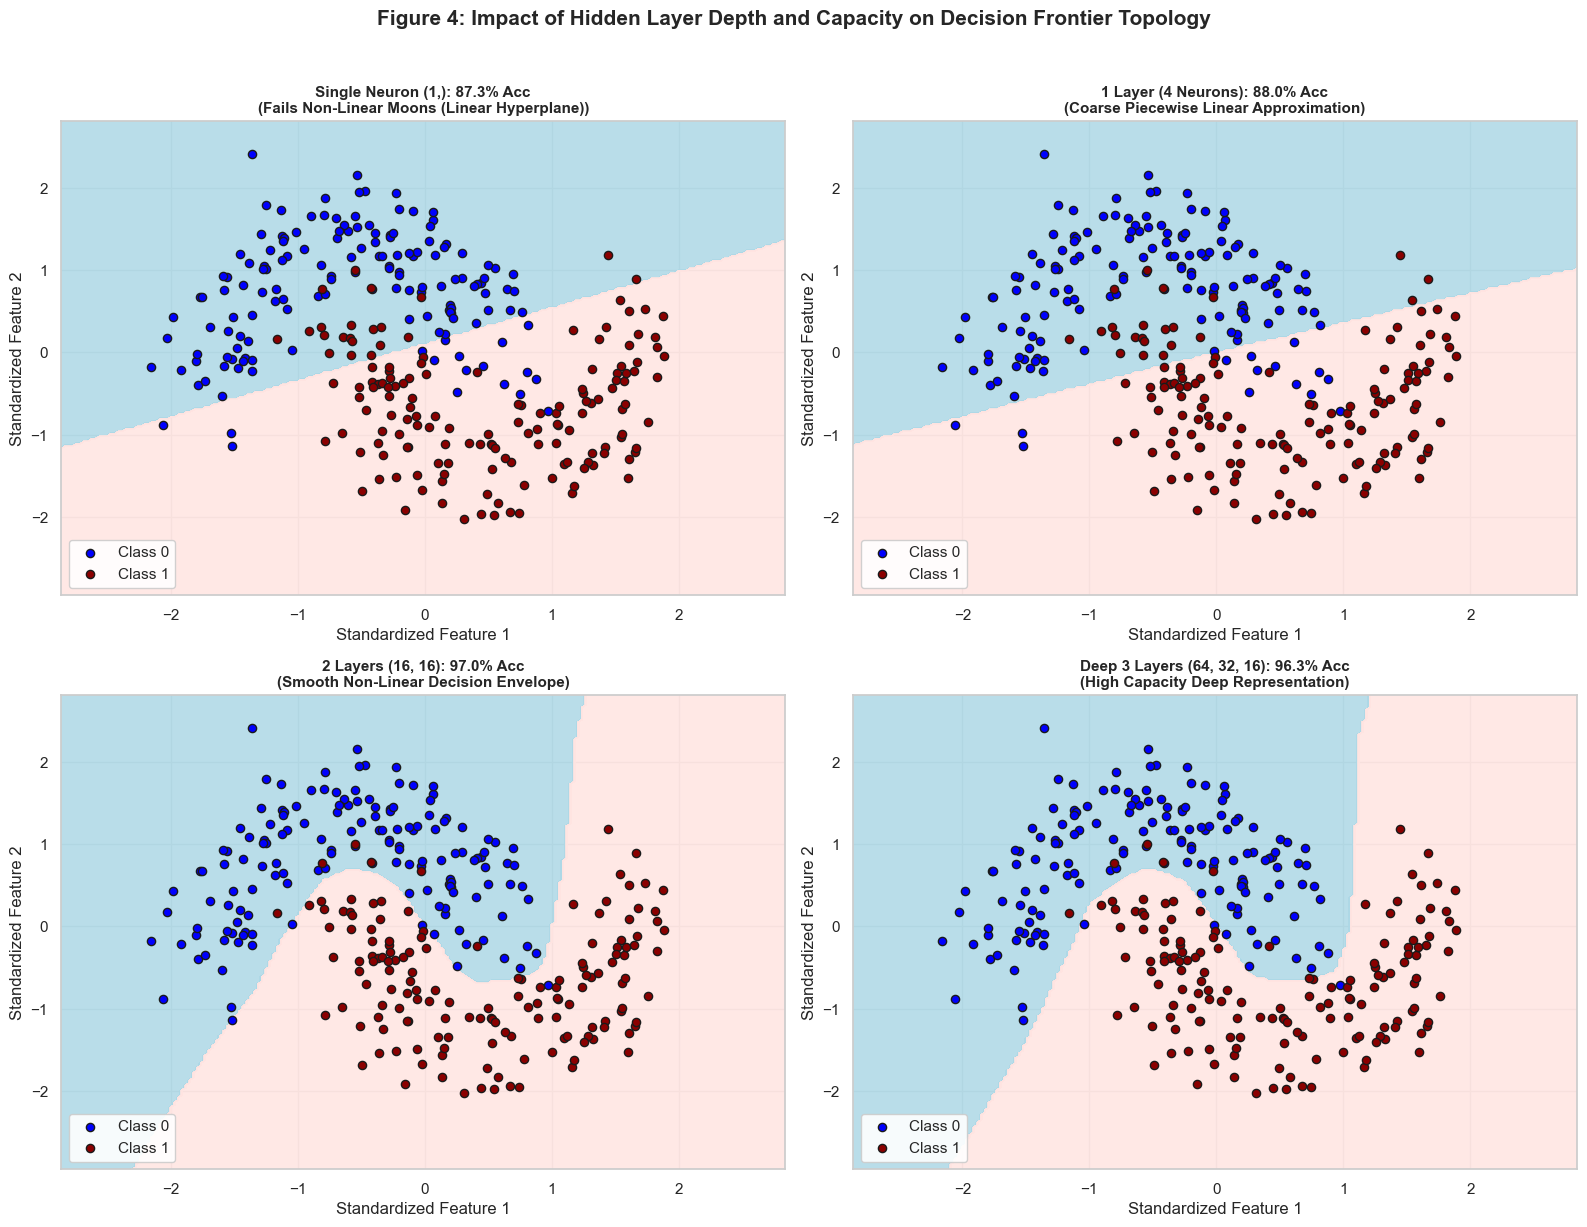

In [6]:
# PLOT 4: 4-Panel Grid of Decision Boundaries across Network Architectures
architectures = [
    ((1,), "Single Neuron (1,)", "Fails Non-Linear Moons (Linear Hyperplane)"),
    ((4,), "1 Layer (4 Neurons)", "Coarse Piecewise Linear Approximation"),
    ((16, 16), "2 Layers (16, 16)", "Smooth Non-Linear Decision Envelope"),
    ((64, 32, 16), "Deep 3 Layers (64, 32, 16)", "High Capacity Deep Representation")
]

x_min, x_max = X_train[:, 0].min() - 0.7, X_train[:, 0].max() + 0.7
y_min, y_max = X_train[:, 1].min() - 0.7, X_train[:, 1].max() + 0.7
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.03), np.arange(y_min, y_max, 0.03))

from matplotlib.colors import ListedColormap
cmap_bg = ListedColormap(['lightblue', 'mistyrose'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (arch, title, subtitle) in enumerate(architectures):
    model = MLPClassifier(hidden_layer_sizes=arch, activation='relu', solver='adam',
                          max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.85)
    axes[idx].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', s=35, edgecolor='k', label='Class 0')
    axes[idx].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkred', s=35, edgecolor='k', label='Class 1')
    axes[idx].set_title(f"{title}: {acc*100:.1f}% Acc\n({subtitle})", fontweight='bold', fontsize=11)
    axes[idx].set_xlabel("Standardized Feature 1")
    axes[idx].set_ylabel("Standardized Feature 2")
    axes[idx].legend(loc='lower left', framealpha=0.9)

plt.suptitle("Figure 4: Impact of Hidden Layer Depth and Capacity on Decision Frontier Topology", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="8-activation-comparison"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 8: Activation Function Comparison on Decision Surfaces (Identity vs Logistic vs Tanh vs ReLU)</span>


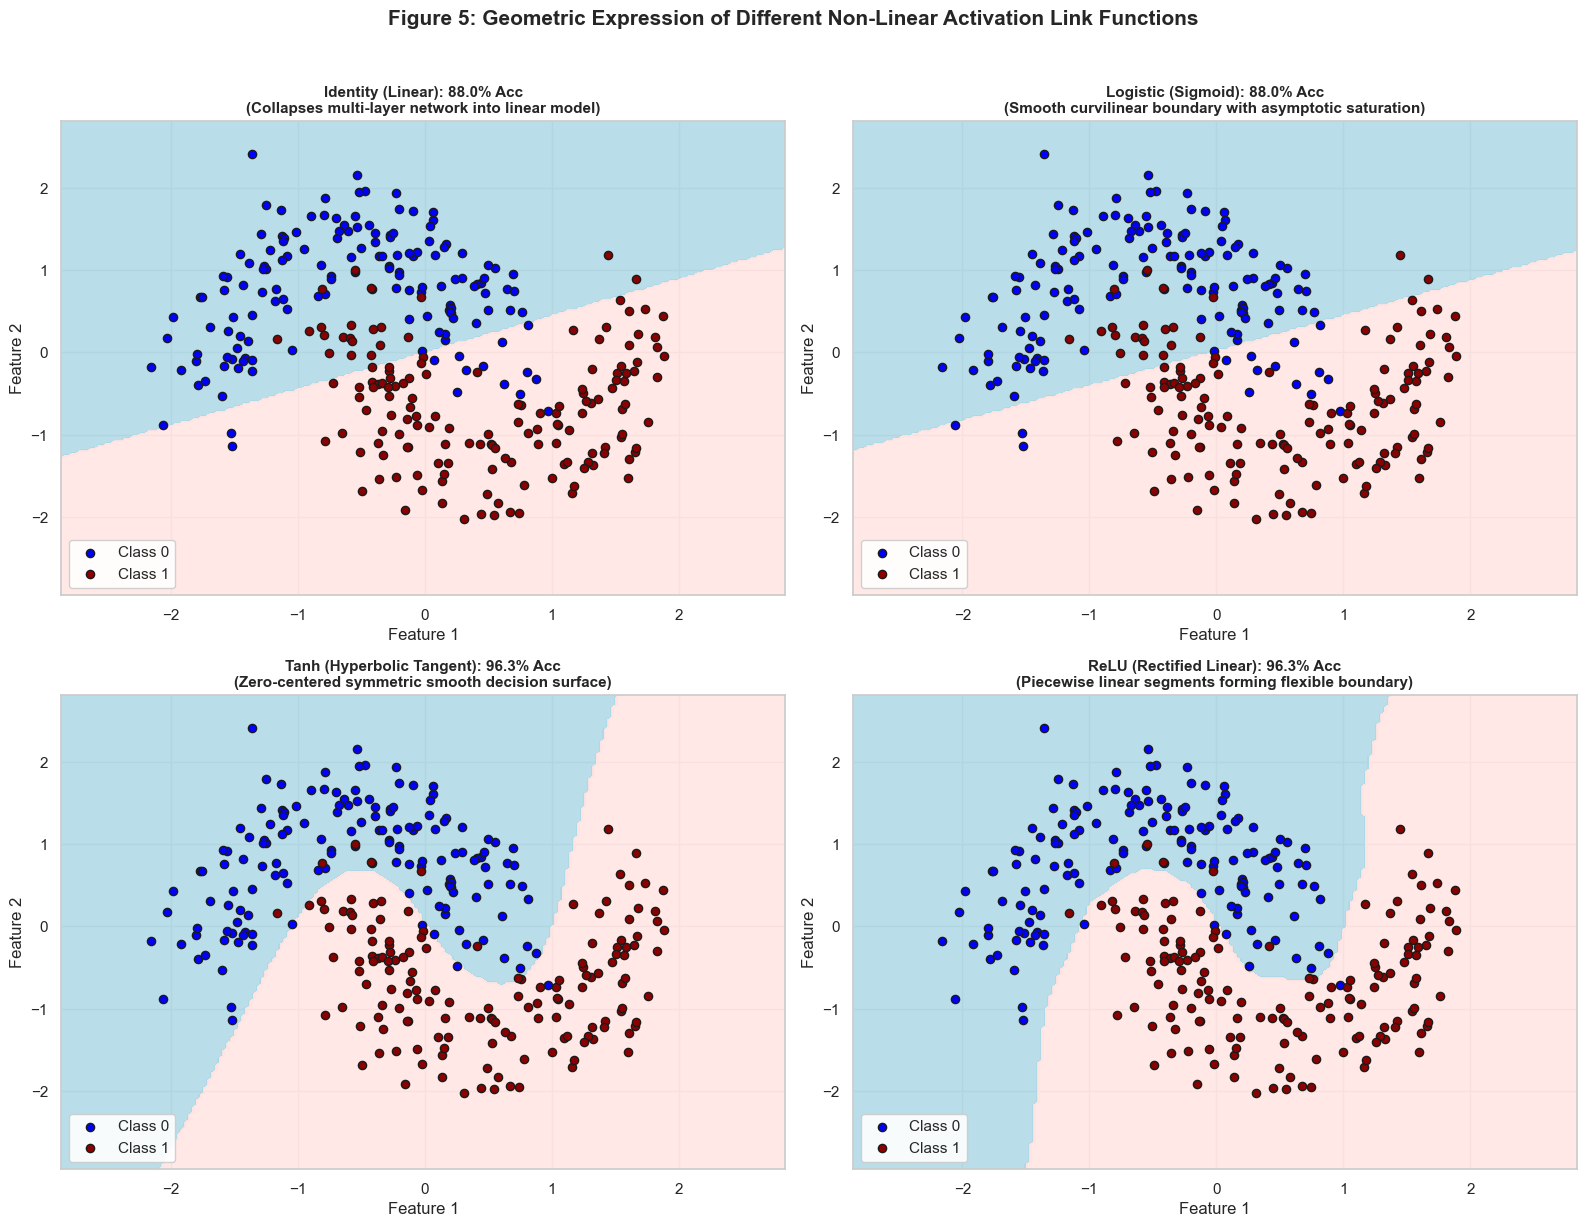

In [7]:
# PLOT 5: 4-Panel Comparison of Decision Frontiers across Activation Functions
acts = ['identity', 'logistic', 'tanh', 'relu']
act_titles = [
    ("Identity (Linear)", "Collapses multi-layer network into linear model"),
    ("Logistic (Sigmoid)", "Smooth curvilinear boundary with asymptotic saturation"),
    ("Tanh (Hyperbolic Tangent)", "Zero-centered symmetric smooth decision surface"),
    ("ReLU (Rectified Linear)", "Piecewise linear segments forming flexible boundary")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (act, (title, subtitle)) in enumerate(zip(acts, act_titles)):
    clf = MLPClassifier(hidden_layer_sizes=(32, 16), activation=act, solver='adam',
                        max_iter=1000, random_state=42)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.85)
    axes[idx].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', s=35, edgecolor='k', label='Class 0')
    axes[idx].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkred', s=35, edgecolor='k', label='Class 1')
    axes[idx].set_title(f"{title}: {acc*100:.1f}% Acc\n({subtitle})", fontweight='bold', fontsize=11)
    axes[idx].set_xlabel("Feature 1")
    axes[idx].set_ylabel("Feature 2")
    axes[idx].legend(loc='lower left', framealpha=0.9)

plt.suptitle("Figure 5: Geometric Expression of Different Non-Linear Activation Link Functions", y=1.02, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="9-regularization-alpha"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Task 9: Regularization & Overfitting Control (L2 Penalty alpha)</span>


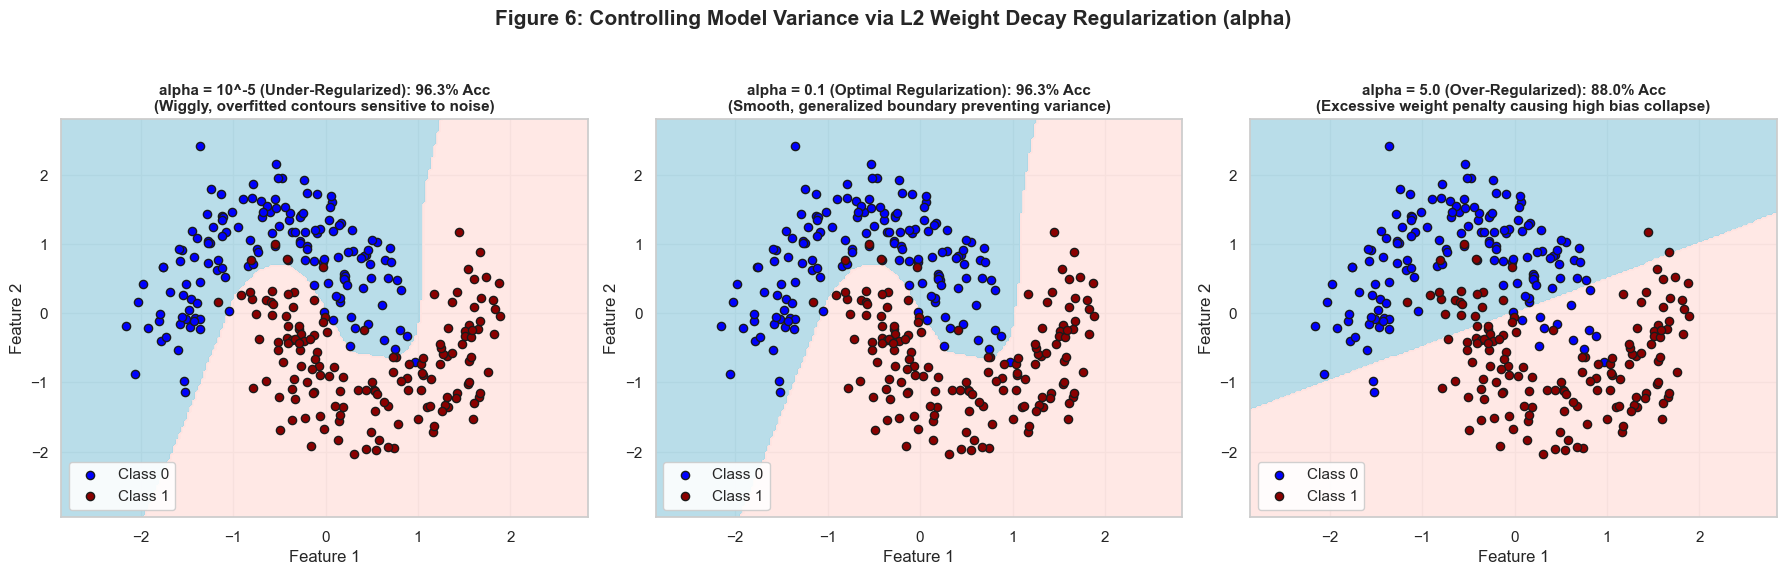

In [8]:
# PLOT 6: 3-Panel Regularization Comparison (L2 Weight Decay alpha)
alphas = [1e-5, 0.1, 5.0]
alpha_descriptions = [
    ("alpha = 10^-5 (Under-Regularized)", "Wiggly, overfitted contours sensitive to noise"),
    ("alpha = 0.1 (Optimal Regularization)", "Smooth, generalized boundary preventing variance"),
    ("alpha = 5.0 (Over-Regularized)", "Excessive weight penalty causing high bias collapse")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for idx, (alpha_val, (title, subtitle)) in enumerate(zip(alphas, alpha_descriptions)):
    clf = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                        alpha=alpha_val, max_iter=1500, random_state=42)
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.85)
    axes[idx].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', s=35, edgecolor='k', label='Class 0')
    axes[idx].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkred', s=35, edgecolor='k', label='Class 1')
    axes[idx].set_title(f"{title}: {acc*100:.1f}% Acc\n({subtitle})", fontweight='bold', fontsize=11)
    axes[idx].set_xlabel("Feature 1")
    axes[idx].set_ylabel("Feature 2")
    axes[idx].legend(loc='lower left', framealpha=0.9)

plt.suptitle("Figure 6: Controlling Model Variance via L2 Weight Decay Regularization (alpha)", y=1.04, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

<a id="10-optimizer-shootout"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">10. Task 10: Optimizer Convergence Shootout (Adam vs SGD with Momentum vs L-BFGS)</span>


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


L-BFGS (Quasi-Newton) converged in 300 iterations with final loss 0.0893 and test accuracy 95.33%


C:\Users\mohdf\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


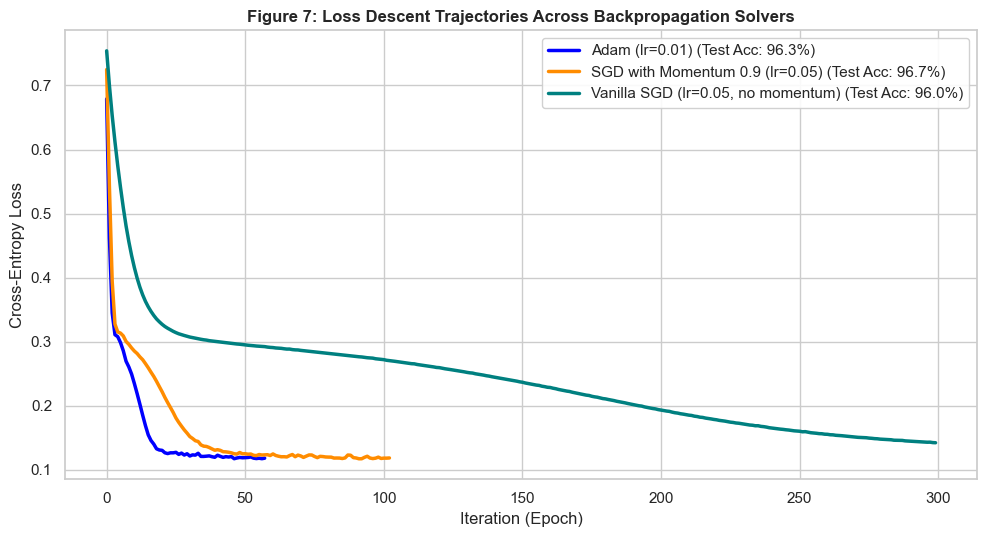

In [9]:
# PLOT 7: Convergence Trajectories Across Neural Network Optimization Solvers
solver_experiments = [
    ('Adam (lr=0.01)', MLPClassifier(hidden_layer_sizes=(32, 16), solver='adam', learning_rate_init=0.01, max_iter=300, random_state=42), 'blue'),
    ('SGD with Momentum 0.9 (lr=0.05)', MLPClassifier(hidden_layer_sizes=(32, 16), solver='sgd', momentum=0.9, learning_rate_init=0.05, max_iter=300, random_state=42), 'darkorange'),
    ('Vanilla SGD (lr=0.05, no momentum)', MLPClassifier(hidden_layer_sizes=(32, 16), solver='sgd', momentum=0.0, learning_rate_init=0.05, max_iter=300, random_state=42), 'teal')
]

plt.figure(figsize=(10, 5.5))

for name, clf, color in solver_experiments:
    clf.fit(X_train, y_train)
    acc = clf.score(X_test, y_test)
    plt.plot(clf.loss_curve_, color=color, linewidth=2.5,
             label=f"{name} (Test Acc: {acc*100:.1f}%)")

# Benchmark L-BFGS separately
clf_lbfgs = MLPClassifier(hidden_layer_sizes=(32, 16), solver='lbfgs', max_iter=300, random_state=42)
clf_lbfgs.fit(X_train, y_train)
acc_lbfgs = clf_lbfgs.score(X_test, y_test)
print(f"L-BFGS (Quasi-Newton) converged in {clf_lbfgs.n_iter_} iterations with final loss {clf_lbfgs.loss_:.4f} and test accuracy {acc_lbfgs*100:.2f}%")

plt.title("Figure 7: Loss Descent Trajectories Across Backpropagation Solvers", fontweight='bold')
plt.xlabel("Iteration (Epoch)")
plt.ylabel("Cross-Entropy Loss")
plt.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

<a id="11-circles-geometry"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">11. Task 11: Generalization Benchmark on Concentric Circles Geometry</span>


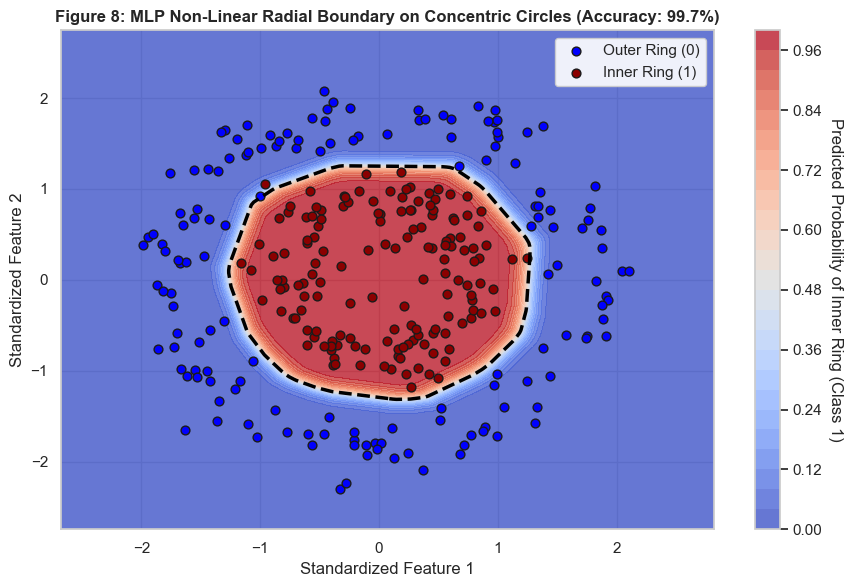

In [10]:
# PLOT 8: Non-Linear Radial Isolation on Concentric Circles
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_circles, y_circles, test_size=0.25, random_state=42, stratify=y_circles
)
scaler_c = StandardScaler()
X_c_train = scaler_c.fit_transform(X_c_train)
X_c_test = scaler_c.transform(X_c_test)

clf_circles = MLPClassifier(hidden_layer_sizes=(32, 32), activation='relu', alpha=0.01,
                            max_iter=1000, random_state=42)
clf_circles.fit(X_c_train, y_c_train)
acc_circles = clf_circles.score(X_c_test, y_c_test)

# Meshgrid for circles
cx_min, cx_max = X_c_train[:, 0].min() - 0.5, X_c_train[:, 0].max() + 0.5
cy_min, cy_max = X_c_train[:, 1].min() - 0.5, X_c_train[:, 1].max() + 0.5
cxx, cyy = np.meshgrid(np.arange(cx_min, cx_max, 0.03), np.arange(cy_min, cy_max, 0.03))

Z_c = clf_circles.predict_proba(np.c_[cxx.ravel(), cyy.ravel()])[:, 1].reshape(cxx.shape)

plt.figure(figsize=(9, 6))
contour = plt.contourf(cxx, cyy, Z_c, 25, cmap='coolwarm', alpha=0.8)
cbar = plt.colorbar(contour)
cbar.set_label("Predicted Probability of Inner Ring (Class 1)", rotation=270, labelpad=15)
plt.contour(cxx, cyy, Z_c, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')

plt.scatter(X_c_test[y_c_test==0, 0], X_c_test[y_c_test==0, 1], c='blue', s=40, edgecolor='k', label='Outer Ring (0)')
plt.scatter(X_c_test[y_c_test==1, 0], X_c_test[y_c_test==1, 1], c='darkred', s=40, edgecolor='k', label='Inner Ring (1)')

plt.title(f"Figure 8: MLP Non-Linear Radial Boundary on Concentric Circles (Accuracy: {acc_circles*100:.1f}%)", fontweight='bold')
plt.xlabel("Standardized Feature 1")
plt.ylabel("Standardized Feature 2")
plt.legend(framealpha=0.9, loc='upper right')
plt.tight_layout()
plt.show()

<a id="12-mlp-gridsearch"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">12. Task 12: Hyperparameter Tuning via GridSearchCV</span>


In [11]:
# Grid Search for Architecture and Regularization on Moons Dataset
param_grid = {
    'hidden_layer_sizes': [(16, 16), (32, 16)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01, 0.1]
}

grid_mlp = GridSearchCV(
    MLPClassifier(solver='adam', max_iter=800, random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
grid_mlp.fit(X_train, y_train)

best_mlp = grid_mlp.best_estimator_
print(f"Optimal Hyperparameters: {grid_mlp.best_params_}")
print(f"Best 5-Fold Cross-Validation Accuracy: {grid_mlp.best_score_ * 100:.2f}%")

Optimal Hyperparameters: {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (16, 16)}
Best 5-Fold Cross-Validation Accuracy: 94.33%


<a id="13-final-evaluation"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">13. Task 13: Final Optimized MLP Model Evaluation (Contour Probability, Confusion Matrix, ROC-AUC)</span>


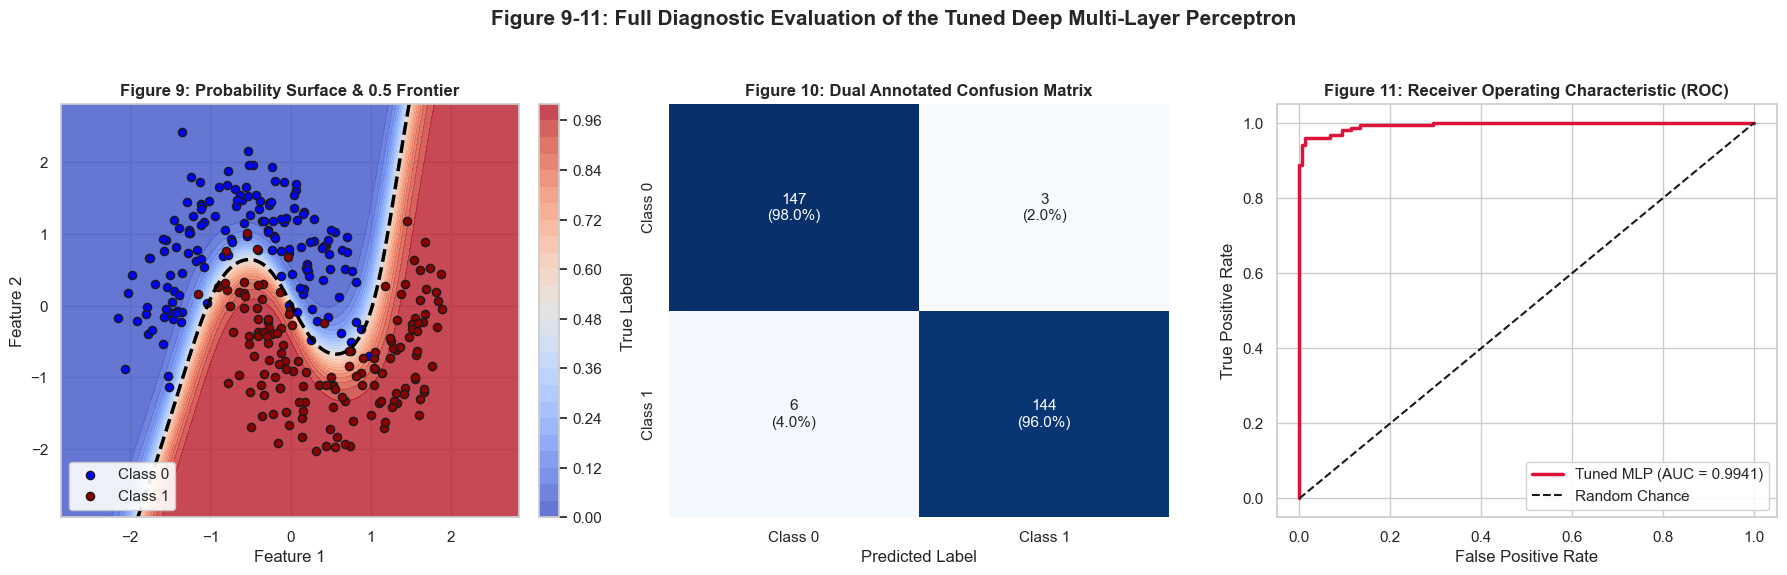

Final Holdout Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       150
           1       0.98      0.96      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



In [12]:
# PLOT 9, 10 & 11: Final Optimized MLP Performance Trinity
y_test_pred = best_mlp.predict(X_test)
y_test_probs = best_mlp.predict_proba(X_test)[:, 1]

fig = plt.figure(figsize=(18, 5.5))

# Subplot 9: High-Resolution Probability Density Surface
ax1 = fig.add_subplot(1, 3, 1)
Z_prob = best_mlp.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
c1 = ax1.contourf(xx, yy, Z_prob, 25, cmap='coolwarm', alpha=0.8)
plt.colorbar(c1, ax=ax1, fraction=0.046, pad=0.04)
ax1.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=2.5, linestyles='--')
ax1.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], c='blue', s=35, edgecolor='k', label='Class 0')
ax1.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], c='darkred', s=35, edgecolor='k', label='Class 1')
ax1.set_title("Figure 9: Probability Surface & 0.5 Frontier", fontweight='bold')
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")
ax1.legend(loc='lower left', framealpha=0.9)

# Subplot 10: Dual Annotated Confusion Matrix
ax2 = fig.add_subplot(1, 3, 2)
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_cm = np.array([[f"{count}\n({norm*100:.1f}%)" for count, norm in zip(row_c, row_n)]
                     for row_c, row_n in zip(cm, cm_norm)])

sns.heatmap(cm, annot=annot_cm, fmt='', cmap='Blues', ax=ax2, cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
ax2.set_title("Figure 10: Dual Annotated Confusion Matrix", fontweight='bold')
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label")

# Subplot 11: ROC-AUC Curve
ax3 = fig.add_subplot(1, 3, 3)
fpr, tpr, _ = roc_curve(y_test, y_test_probs)
roc_score = auc(fpr, tpr)
ax3.plot(fpr, tpr, color='crimson', linewidth=2.5, label=f'Tuned MLP (AUC = {roc_score:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Chance')
ax3.set_title("Figure 11: Receiver Operating Characteristic (ROC)", fontweight='bold')
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend(loc='lower right', framealpha=0.9)

plt.suptitle("Figure 9-11: Full Diagnostic Evaluation of the Tuned Deep Multi-Layer Perceptron", y=1.04, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print("Final Holdout Classification Report:")
print(classification_report(y_test, y_test_pred))

<a id="14-summary-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">14. Task 14: Deep Learning Engineering Takeaways & Scaling to Deep Architectures</span>


### 🚀 Deep Learning Engineering Takeaways

1. **Why Neural Networks Excel on Non-Linear Geometries**:
   - Single linear models (e.g. Logistic Regression) can only draw planar hyperplanes.
   - Hidden layers with non-linear activation functions (ReLU, Tanh) warp feature space, enabling the network to carve out arbitrary decision surfaces.

2. **Feature Scaling is Non-Negotiable**:
   - Neural network weights are updated via gradient descent:

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla \mathcal{L}
$$

   - Unscaled features create elongated, ill-conditioned loss surfaces, causing oscillatory updates and slow or failed convergence.

3. **Scikit-Learn MLP vs PyTorch/TensorFlow**:
   - Scikit-learn's `MLPClassifier` is an excellent tool for tabular data, rapid prototyping, and non-linear classification without heavy GPU dependencies.
   - For massive datasets ($>10^6$ rows), computer vision (CNNs), sequential text (Transformers), or GPU acceleration, transition to frameworks like PyTorch or TensorFlow.
